In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from tqdm.auto import tqdm
import copy
import random, unicodedata
import glob
import hashlib
import math
from collections import defaultdict
C_TRAIN, C_VAL = '#2a78d6', '#eb6834'
INK, INK2, MUTED, SURF = '#0b0b0b', '#52514e', '#b8b7b2', '#fcfcfb'
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    'seq', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#1c5cab', '#0d366b'])

In [ ]:
"""Parse the Tatoeba/Anki tur.txt and split it WITHOUT leaking.

Format is TSV: <english>\t<turkish>\t<attribution>
The parsing is one line. Everything else here is about the two traps:
  1. one English sentence maps to MANY Turkish sentences  -> split leakage
  2. the file is sorted by length                          -> distribution shift
"""
torch.set_printoptions(precision=3, sci_mode=False, linewidth=200)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def normalize_common(s: str) -> str:
    s = unicodedata.normalize("NFC", s)

    # Remove unwanted invisible characters
    s = s.replace("\u00a0", " ")  # Non-breaking space
    s = s.replace("\u00ad", "")   # Soft hyphen
    s = s.replace("\u200b", "")   # Zero-width space

    # strip Latin diacritics
    s = s.replace("á", "a").replace("Á", "A")
    s = s.replace("à", "a").replace("À", "A")
    s = s.replace("é", "e").replace("É", "E")
    s = s.replace("è", "e").replace("È", "E")
    s = s.replace("í", "i").replace("Í", "I")
    s = s.replace("ì", "i").replace("Ì", "I")
    s = s.replace("ó", "o").replace("Ó", "O")
    s = s.replace("ò", "o").replace("Ò", "O")
    s = s.replace("ú", "u").replace("Ú", "U")
    s = s.replace("ù", "u").replace("Ù", "U")
    s = s.replace("ã", "a").replace("Ã", "A")
    s = s.replace("ñ", "n").replace("Ñ", "N")
    s = s.replace("õ", "o").replace("Õ", "O")
    s = s.replace("î", "i").replace("Î", "I")
    s = s.replace("ï", "i").replace("Ï", "I")
    s = s.replace("’", "'")  # curly apostrophe
    s = s.replace("‘", "'")  # left curly apostrophe

    # Correct the degree symbol
    s = s.replace("º", "°")

    return s.strip()

def normalize_turkish(s: str) -> str:
    s = normalize_common(s)                 # precompose Ö, ş, ğ ...
    # Correct Romanian-style s to Turkish ş
    s = s.replace("Ș", "Ş").replace("ș", "ş")
    s = s.replace("ì", "ı").replace("Ì", "I")

    # Handle Turkish I and İ
    s = s.replace("İ", "i")
    s = s.replace("I", "ı")
    s = s.replace("i\u0307", "i")
    
    return s.lower()

def normalize_english(s: str) -> str:
    s = normalize_common(s)
    s = s.replace("ì", "i").replace("Ì", "I")
    return s.lower()

def load_tatoeba(path):
    pairs = []
    with open(path, encoding="utf-8") as f:
        for ln, line in enumerate(f, 1):
            line = line.rstrip("\n").rstrip("\r") #remove line endings ('n' for unix, 'rn' for windows)

            if not line.strip(): #an empty string ("") to be false
                print(f"  skipping empty line {ln}")
                continue

            parts = line.split("\t")

            if len(parts) < 2:
                print(f"  skipping malformed line {ln}: {line[:60]!r}")
                continue

            en, tr = parts[0].strip(), parts[1].strip()   # parts[2:] = attribution

            if not en or not tr:
                print(f"  skipping line {ln}: {line[:60]!r}")
                continue

            pairs.append((en, tr))
            
    return pairs


pairs = load_tatoeba("tatoeba_en_tur.txt")
print(f"parsed {len(pairs)} rows\n")
    
normalized_pairs = [
    (normalize_english(en), normalize_turkish(tr))
    for en, tr in pairs
]

r = np.array([len(t) / max(len(e), 1) for e, t in normalized_pairs])
Lr = np.array([len(t) for _, t in normalized_pairs])
Le = np.array([len(e) for e, _ in normalized_pairs])
print(f"tr length:   median {np.median(Lr):.0f}  p99 {np.percentile(Lr,99):.0f}  max {Lr.max()}")
print(f"en length:   median {np.median(Le):.0f}  p99 {np.percentile(Le,99):.0f}  max {Le.max()}")
print(f"tr/en ratio: median {np.median(r):.2f}  p99 {np.percentile(r,99):.2f}  max {r.max():.2f}")

#cut the outlier sequences to a reasonable length for block size T. 
# print information
Le = np.array([len(e) for e, _ in normalized_pairs])
Lt = np.array([len(t) for _, t in normalized_pairs])
for cut in (48, 56, 64, 72, 80, 96, 128):
    keep = (Le <= cut - 1) & (Lt <= cut - 1)
    T = cut + 1
    pad = 1 - Lt[keep].mean() / T
    print(f"  T={T:4d}  keep {keep.mean()*100:5.1f}%  "
          f"({keep.sum():,} rows)  PAD {pad*100:4.1f}%  attn {(T/73)**2:5.2f}x") # attn: estimates the relative computational cost of the Transformer's attention mechanism compared with a reference sequence length of 73 tokens

T_en = T_tr = 64                       # final padded width, EOS/BOS included
 # we had to use temporary tokenizer since encode_en and encode_tr are defined later after the vocabularies are built
 # If we swap in BPE it is is trained once on the raw text and we won't need encode_en and encode_tr to be defined before the vocabularies are built.
tokenize_en = lambda s: list(normalize_english(s))     
tokenize_tr = lambda s: list(normalize_turkish(s))
filtered_pairs = [
    (en, tr)
    for en, tr in normalized_pairs
    if len(tokenize_en(en)) + 1 <= T_en
    and len(tokenize_tr(tr)) + 1 <= T_tr
]

removed = len(normalized_pairs) - len(filtered_pairs)
print(f"Original pairs: {len(normalized_pairs)}")
print(f"Removed pairs:  {removed}")
print(f"Remaining:      {len(filtered_pairs)}")
print(f"Retained:       {100 * len(filtered_pairs) / len(normalized_pairs):.2f}%")

normalized_pairs = filtered_pairs
print(f"kept {len(normalized_pairs):,} pairs, T_en={T_en}, T_tr={T_tr}")   

# Shuffle the unique English source keys using grouping "1 to any translations"
#   This shuffle prevents the original file order from determining the training/validation split while keeping every translation of the same English sentence in one dataset

# Group all pairs by their normalized English source.
groups_by_en = defaultdict(list)

for en, tr in normalized_pairs:
    groups_by_en[en].append(tr)

keys = sorted(groups_by_en)
rng = random.Random(0)
rng.shuffle(keys)

# Split by unique source, not by individual rows.
n = int(0.9 * len(keys))

# now train and the val sets are randomized by unique suhuffled English source
train_keys, val_keys = set(keys[:n]), set(keys[n:])

tr_rows = [(e, t) for e, t in normalized_pairs if e in train_keys]
va_rows = [(e, t) for e, t in normalized_pairs if e in val_keys]

#versioning
split_id = hashlib.md5("|".join(sorted(val_keys)).encode()).hexdigest()[:12]
print("split fingerprint:", split_id)     # must match across restarts

# Shuffle rows within the datasets to avoid any ordering bias from the original file.
rng.shuffle(tr_rows)
rng.shuffle(va_rows)

#create the mappings for the vocabularies
PAD, BOS, EOS = "_", ">", "<"  # special tokens for padding, beginning of sentence, and end of sentence
reserved = set("_><")

unique_chars_english = sorted(set(ch for e, _ in normalized_pairs for ch in e))
unique_chars_turkish = sorted(set(ch for _, t in normalized_pairs for ch in t))
assert not reserved.intersection(unique_chars_english)
assert not reserved.intersection(unique_chars_turkish)

special_tokens = [PAD, BOS, EOS, "<UNK>"]

# English vocabulary
vocab_en = special_tokens + unique_chars_english
stoi_en = {ch:i for i, ch in enumerate(vocab_en)}
itos_en = {i: ch for ch, i in stoi_en.items()}

encode_en = lambda s: [stoi_en.get(ch, stoi_en["<UNK>"]) for ch in tokenize_en(s)]
decode_en = lambda l: "".join(itos_en[i] for i in l)

assert sum(tok == stoi_en['<UNK>'] for e, _ in normalized_pairs for tok in encode_en(e)) == 0

# Turkish vocabulary
vocab_tr = special_tokens + unique_chars_turkish
stoi_tr = {ch:i for i, ch in enumerate(vocab_tr)}
itos_tr = {i: ch for ch, i in stoi_tr.items()}

encode_tr = lambda s: [stoi_tr.get(ch, stoi_tr["<UNK>"]) for ch in tokenize_tr(s)]
decode_tr = lambda l: "".join(itos_tr[i] for i in l)

assert sum(tok == stoi_tr['<UNK>'] for _, t in normalized_pairs for tok in encode_tr(t)) == 0

pad_id_tr = stoi_tr[PAD]  # 0
bos_id_tr = stoi_tr[BOS]  # 1
eos_id_tr = stoi_tr[EOS]  # 2

pad_id_en = stoi_en[PAD]  # 0
bos_id_en = stoi_en[BOS]  # 1
eos_id_en = stoi_en[EOS]  # 2

#prepare the training and validation tensor datasets
def add_padding_to_encoded(encoded_list, max_block_size_T, pad_id):
    assert len(encoded_list) <= max_block_size_T, f"sequence of {len(encoded_list)} exceeds T={max_block_size_T}"
    return torch.tensor(list(encoded_list) + [pad_id] * (max_block_size_T - len(encoded_list)))

# We calculate the max length of the encoded sequences though in our tokens are characters but we might change in the future to subwords or words so we keep the naming of T_en and T_tr
enc_en = [encode_en(e) for e, _ in normalized_pairs]
enc_tr = [encode_tr(t) for _, t in normalized_pairs]

T_en_max = max(len(x) for x in enc_en) + 1  # +1 for EOS
T_tr_max = max(len(x) for x in enc_tr) + 1  # +1 for BOS or EOS

print(f"Double Check max block size, T_en_max={T_en_max}, T_tr_max={T_tr_max}")    
assert(T_en_max == T_en), f"max English sequence length {T_en_max} is not equal to T_en={T_en}"
assert(T_tr_max == T_tr), f"max Turkish sequence length {T_tr_max} is not equal to T_tr={T_tr}"

vocab_size_en, vocab_size_tr = len(vocab_en), len(vocab_tr)

source_train = torch.stack([add_padding_to_encoded(encode_en(e) + [eos_id_en], T_en_max, pad_id_en) for e, _ in tr_rows])
target_decoder_in_train = torch.stack([add_padding_to_encoded([bos_id_tr] + encode_tr(t), T_tr_max, pad_id_tr) for _, t in tr_rows]) #right-shifted target for decoder input (with BOS)
target_decoder_out_train = torch.stack([add_padding_to_encoded(encode_tr(t) + [eos_id_tr], T_tr_max, pad_id_tr) for _, t in tr_rows]) #target for loss computation

source_val = torch.stack([add_padding_to_encoded(encode_en(e) + [eos_id_en], T_en_max, pad_id_en) for e, _ in va_rows])
target_decoder_in_val = torch.stack([add_padding_to_encoded([bos_id_tr] + encode_tr(t), T_tr_max, pad_id_tr) for _, t in va_rows])
target_decoder_out_val = torch.stack([add_padding_to_encoded(encode_tr(t) + [eos_id_tr], T_tr_max, pad_id_tr) for _, t in va_rows])

print(f"English vocab:", vocab_size_en)
print("English chars:", unique_chars_english)
print(f"Turkish vocab:", vocab_size_tr)
print("Turkish chars:", unique_chars_turkish)

print(f"{len(normalized_pairs):,} rows -> {len(groups_by_en):,} unique English sources")
print(f"train {len(tr_rows):,} rows / val {len(va_rows):,} rows "
      f"({len(va_rows)/len(normalized_pairs)*100:.1f}% of rows)")

parsed 522979 rows

tr length:   median 31  p99 72  max 490
en length:   median 31  p99 70  max 537
tr/en ratio: median 1.00  p99 1.67  max 5.40
  T=  49  keep  85.1%  (444,933 rows)  PAD 40.7%  attn  0.45x
  T=  57  keep  93.3%  (487,724 rows)  PAD 46.1%  attn  0.61x
  T=  65  keep  97.0%  (507,081 rows)  PAD 51.3%  attn  0.79x
  T=  73  keep  98.6%  (515,783 rows)  PAD 55.9%  attn  1.00x
  T=  81  keep  99.4%  (519,662 rows)  PAD 59.9%  attn  1.23x
  T=  97  keep  99.8%  (522,023 rows)  PAD 66.3%  attn  1.77x
  T= 129  keep 100.0%  (522,852 rows)  PAD 74.6%  attn  3.12x
Original pairs: 522979
Removed pairs:  15898
Remaining:      507081
Retained:       96.96%
kept 507,081 pairs, T_en=64, T_tr=64
Double Check max block size, T_en_max=64, T_tr_max=64
English vocab: 60
English chars: [' ', '!', '"', '$', '%', '&', "'", '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 

In [117]:
source_train[0], target_decoder_in_train[0], target_decoder_out_train[0]


(tensor([53, 43, 49,  4, 41, 49, 47, 48, 42, 10, 48,  4, 32, 33, 44, 33, 42, 32,  4, 43, 42,  4, 43, 48, 36, 33, 46, 47,  4, 34, 43, 46,  4, 36, 33, 40, 44, 14,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 tensor([ 1, 53, 29, 46, 32, 63, 41,  4, 37, 58, 37, 42,  4, 30, 29, 64, 39, 29, 40, 29, 46, 63, 42, 29,  4, 30, 29, 62, 63, 41, 40, 63,  4, 43, 40, 41, 29, 41, 29, 40, 63, 47, 63, 42, 63, 54, 14,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 tensor([53, 29, 46, 32, 63, 41,  4, 37, 58, 37, 42,  4, 30, 29, 64, 39, 29, 40, 29, 46, 63, 42, 29,  4, 30, 29, 62, 63, 41, 40, 63,  4, 43, 40, 41, 29, 41, 29, 40, 63, 47, 63, 42, 63, 54, 14,  2,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]))

In [3]:
@dataclass
class Config:
    def __init__(self):
        self.manual_seed: int = 1337
        self.eval_iters: int = 200
        self.max_iters: int = 5000
        self.eval_interval: int = 500
        self.batch_size: int = 64 # = B
        self.block_size_source_T: int = 64
        self.block_size_target_T: int = 64
        self.learning_rate: float = 3e-4
        self.n_embd: int = 384 # (n_head * head_size) = C, number of channels
        self.n_head: int = 6   
        self.head_size: int = self.n_embd // self.n_head    # (n_embd/n_head): convention
        self.n_layer: int = 6 
        self.dropout: float = 0.2

class AttentionHead(nn.Module):

    def __init__(self, num_embedding_C, head_size_Hs, max_block_size_T, masked=True, dropout=0.2) -> None:
        super().__init__()
        self.num_embedding_C = num_embedding_C
        self.head_size_Hs = head_size_Hs
        self.masked = masked
        # Query can come from a different context
        self.w_query = nn.Linear(in_features=self.num_embedding_C, out_features=self.head_size_Hs, bias=False)
        # Key and Value should come from the same source
        self.w_key = nn.Linear(in_features=self.num_embedding_C, out_features=self.head_size_Hs, bias=False)
        self.w_value = nn.Linear(in_features=self.num_embedding_C, out_features=self.head_size_Hs, bias=False)
        self.tril: torch.Tensor
        self.register_buffer('tril', torch.tril(torch.ones(max_block_size_T, max_block_size_T)), persistent=False) # Buffers go into state_dict(). tril is a recomputable constant, so saving 108 copies of the same lower-triangular matrix is pure overhead
        self.dropout = nn.Dropout(dropout)


    def forward(self, x_query_src , x_memory_keyvalue_src=None, pad_mask_kv=None):

        kv = x_query_src if x_memory_keyvalue_src is None else x_memory_keyvalue_src

        Q = self.w_query(x_query_src)     # arg 1 is ALWAYS the query source (= the residual stream)
        K = self.w_key(kv) # [B, T_kv, C] x [C, Hs] = [B, T_kv, Hs]
        V = self.w_value(kv) # [B, T_kv, Hs]

        dim_k = K.shape[-1] # = Hs
        inv_sqrt_dim_k = (dim_k ** -0.5)
        
        attention_scores = (Q @ K.transpose(-2, -1)) * inv_sqrt_dim_k # [B, T_q, Hs] @ [B, Hs, T_kv] = [B, T_q, T_kv]

        if self.masked: # causal: decoder SELF-attention only
            T_q, T_kv = attention_scores.shape[-2], attention_scores.shape[-1]
            assert T_q == T_kv, f"causal mask needs T_q == T_kv, got {T_q} vs {T_kv}"
            attention_scores = attention_scores.masked_fill(self.tril[:T_q, :T_kv] == 0, float('-inf')) # masked attention

        if pad_mask_kv is not None:
            pad_mask_kv_extended = pad_mask_kv[:, None, :] # [B, T_kv] to --> [B, 1, T_kv]
            attention_scores = attention_scores.masked_fill(pad_mask_kv_extended, float('-inf')) # [B, 1, T_kv] broadcast "ignored T_kv" to attention_scores[B, T_q, T_kv] for every row of T_q

        attention_map = F.softmax(attention_scores, dim=-1) #[B, T_q, T_kv]
        attention_map = self.dropout(attention_map)

        z = attention_map @ V # [B, T_q, T_kv] @ [B, T_kv, Hs] = [B, T_q, Hs]

        return z

class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, num_embedding_C, head_size_Hs, max_block_size_T, masked, dropout=0.2) -> None:
        super().__init__()
        self.attention_heads = nn.ModuleList([AttentionHead(num_embedding_C, head_size_Hs, max_block_size_T, masked, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(in_features=num_heads*head_size_Hs, out_features=num_embedding_C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_query_src, x_memory_keyvalue_src=None, pad_mask_kv=None):
        x = torch.cat([h(x_query_src, x_memory_keyvalue_src, pad_mask_kv) for h in self.attention_heads], dim=-1) #cat([B, T, Hs], [B, T, Hs], [B, T, Hs] ...num_heads) cat on Hs, the last column = -1
        out = self.proj(x) # B, T, Hs*num_heads] @ [Hs*num_heads, C] = [B, T, C]
        out = self.dropout(out)
        return out

class FeedForward(nn.Module):

    def __init__(self, num_embedding_C, dropout=0.2) -> None:
        super().__init__()
        # inner layer must EXPAND by 4x ("d_ff = 2048 for d_model = 512", Vaswani 3.3)
        self.ff = nn.Sequential(nn.Linear(num_embedding_C, 4 * num_embedding_C),
                                nn.ReLU(),
                                nn.Linear(4 * num_embedding_C, num_embedding_C),
                                nn.Dropout(dropout))

    def forward(self, X):
        #Input X from MultiHeadAttention output [B, T, C]
        return self.ff(X)

class EncoderResidualBlock(nn.Module):

    def __init__(self, num_heads, num_embedding_C, head_size_Hs, max_block_size_T, dropout=0.2):
        super().__init__()
        self.self_mha = MultiHeadAttention(num_heads, num_embedding_C, head_size_Hs, max_block_size_T, masked=False, dropout=dropout)
        self.ffwd = FeedForward(num_embedding_C, dropout)
        self.layer_norm1 = nn.LayerNorm(num_embedding_C)
        self.layer_norm2 = nn.LayerNorm(num_embedding_C)
 
    def forward(self, X_source_memory, pad_mask_source_memory):
        x1 = X_source_memory + self.self_mha(self.layer_norm1(X_source_memory), x_memory_keyvalue_src=None, pad_mask_kv=pad_mask_source_memory)
        x2 = x1   + self.ffwd(self.layer_norm2(x1))
        return x2

class DecoderResidualBlock(nn.Module): #the masked is True for decoder, no information from the future sequences

    def __init__(self, num_heads, num_embedding_C, head_size_Hs, max_block_size_T, dropout=0.2) -> None:
        super().__init__()
        self.self_mha = MultiHeadAttention(num_heads, num_embedding_C, head_size_Hs, max_block_size_T, masked=True, dropout = dropout)
        self.cross_mha = MultiHeadAttention(num_heads, num_embedding_C, head_size_Hs, max_block_size_T, masked=False, dropout = dropout)

        self.ffwd = FeedForward(num_embedding_C, dropout)
        self.layer_norm1 = nn.LayerNorm(num_embedding_C)
        self.layer_norm2 = nn.LayerNorm(num_embedding_C)
        self.layer_norm3 = nn.LayerNorm(num_embedding_C)

    def forward(self, X_target, X_source_memory, pad_mask_target, pad_mask_source_memory):
        #Input is Token_Embeddings + Positional Embeddings [B, T, C]
        x1 =  X_target + self.self_mha(self.layer_norm1(X_target), x_memory_keyvalue_src=None, pad_mask_kv=pad_mask_target)
        x2 =  x1 + self.cross_mha(self.layer_norm2(x1), X_source_memory, pad_mask_kv=pad_mask_source_memory)
        x3 =  x2 + self.ffwd(self.layer_norm3(x2))
        return x3

class Translator(nn.Module):
    def __init__(self, vocab_size_source, vocab_size_target, block_size_source_T, block_size_target_T, num_embedding_C, attention_head_size_Hs, num_multi_attention_head_Hn, num_transformer_layer_Nx, pad_id_source, pad_id_target, dropout = 0.2):
        super().__init__()
        self.vocab_size_source = vocab_size_source
        self.vocab_size_target = vocab_size_target
        self.block_size_source_T = block_size_source_T
        self.block_size_target_T = block_size_target_T
        self.num_embedding_C = num_embedding_C
        self.head_size_Hs = attention_head_size_Hs
        self.num_heads = num_multi_attention_head_Hn
        self.num_transformer_layer_Nx = num_transformer_layer_Nx
        self.dropout = dropout
        self.pad_id_source = pad_id_source
        self.pad_id_target = pad_id_target

        # Source (currently english) Embeddings
        self.token_embeddings_source = nn.Embedding(num_embeddings=self.vocab_size_source, embedding_dim=self.num_embedding_C)
        self.position_embeddings_source = nn.Embedding(num_embeddings=self.block_size_source_T, embedding_dim=self.num_embedding_C)

        #Target (currently turkish embeddings)
        self.token_embeddings_target = nn.Embedding(num_embeddings=self.vocab_size_target, embedding_dim=self.num_embedding_C)
        self.position_embeddings_target = nn.Embedding(num_embeddings=self.block_size_target_T, embedding_dim=self.num_embedding_C)

        # nn.Sequential (nn.Sequential(*[DecoderBlock(...)) tells the next reader "call me as a pipeline", which is not true here since forward method ("forward(self, X, pad_mask, ...)") takes more argument not just forward(self, X) which cannot be called sequentially
        # nn.ModuleList says "I'm a registered list; the loop is yours to write,"
        self.target_decoder_blocks = nn.ModuleList([DecoderResidualBlock(self.num_heads, self.num_embedding_C, self.head_size_Hs, self.block_size_target_T, self.dropout) for _ in range(self.num_transformer_layer_Nx)])
        self.source_encoder_blocks = nn.ModuleList([EncoderResidualBlock(self.num_heads, self.num_embedding_C, self.head_size_Hs, self.block_size_source_T, self.dropout) for _ in range(self.num_transformer_layer_Nx)])     

        self.last_layernorm_head = nn.LayerNorm(self.num_embedding_C)
        self.last_linear_head = nn.Linear(in_features=self.num_embedding_C, out_features=self.vocab_size_target)        

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02) #nn.init functions already use torch.no_grad() internally.
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02) #The trailing underscore is a PyTorch convention for in-place operations

    def encode(self, X_src_memory, pad_mask_source):
        T = X_src_memory.shape[1] # src: [B, T]
        
        source_token_embedding = self.token_embeddings_source(X_src_memory) # [B, T, C]
        source_position_embedding = self.position_embeddings_source(torch.arange(T, device=X_src_memory.device)) # [B, T, C]

        x = source_token_embedding + source_position_embedding

        for blk in self.source_encoder_blocks:
            x = blk(X_source_memory = x , pad_mask_source_memory = pad_mask_source) #forward blocks sequentially
       
        return x

    def decode(self, target_in, encoded_source_memory, pad_mask_target, pad_mask_source_memory):
        T = target_in.shape[1] # target: [B, T]

        target_token_embedding = self.token_embeddings_target(target_in) # [B, T, C]
        target_position_embedding = self.position_embeddings_target(torch.arange(T, device=target_in.device)) # [B, T, C]

        x = target_token_embedding + target_position_embedding

        #X_target, X_source_memory, pad_mask_target, pad_mask_source_memory
        for blk in self.target_decoder_blocks:
            x = blk(X_target = x, X_source_memory = encoded_source_memory, pad_mask_target = pad_mask_target, pad_mask_source_memory = pad_mask_source_memory)

        target_logits = self.last_linear_head(self.last_layernorm_head(x)) 

        return target_logits # [B, T, V_target]

    def forward(self, src_memory, tgt_in, tgt_out=None):

        #create padding masked to be ignore when TRUE (to be assigned -inf)
        pad_mask_source = (src_memory == self.pad_id_source)
        pad_mask_target_in = (tgt_in == self.pad_id_target)
        
        encoded_source = self.encode(X_src_memory = src_memory, pad_mask_source = pad_mask_source)
        logits_target = self.decode(target_in = tgt_in, encoded_source_memory = encoded_source, pad_mask_target = pad_mask_target_in, pad_mask_source_memory = pad_mask_source)
        loss = None

        if tgt_out is not None:
            # view is a pure re-stride: it needs the existing strides to be compatible with the new shape
            # reshape tries view first and silently falls back to contiguous().view() (more defensive)
            # "logits_target.view(B*T, V_target) --> explicit", "logits_tr.reshape(-1, self.vocab_size_target)" --> inferred

            loss = F.cross_entropy(logits_target.reshape(-1, self.vocab_size_target),
                                   tgt_out.reshape(-1), ignore_index=self.pad_id_target)

        return logits_target, loss

    # Generate new tokens based on respective last token of a sequence
    # idx = [B, T] where B = 1
    # when B > 1 B times candidate outputs to be generated (on roughly the cost of B=1)
    @torch.no_grad()
    def translate(self, src_en, max_new_tokens=20): 
        was_training = self.training                
        self.eval() # dropout OFF while sampling

        try:
            pad_mask_source = (src_en == pad_id_en)
            source_memory_encoded = self.encode(X_src_memory = src_en, pad_mask_source = pad_mask_source) # ONCE

            tgt_tr = torch.full((src_en.shape[0], 1), bos_id_tr, dtype=torch.long, device=src_en.device)        

            for _ in range(max_new_tokens):
                tgt_cond  = tgt_tr[:, -self.block_size_target_T:]
                pad_mask_target = (tgt_cond == pad_id_tr)
                
                logits_tr = self.decode(target_in = tgt_cond, encoded_source_memory = source_memory_encoded, pad_mask_target = pad_mask_target, pad_mask_source_memory = pad_mask_source)
                
                next_tr   = logits_tr[:, -1, :].argmax(-1, keepdim=True)
                tgt_tr    = torch.cat([tgt_tr, next_tr], dim=1)

                if (next_tr == eos_id_tr).all():
                        break

            return tgt_tr
        finally:
            self.train(was_training)

In [ ]:
  # in encoder-decoder architecture returns 3 tensors
  # data is a table of pre-padded rows, ix means a row index
  # block_size argument is not used since T is baked into the tensor by padding
def getBatch(split, batch_size, generator=None): 
    src, din, dout = (source_train, target_decoder_in_train, target_decoder_out_train) if split == 'train' else (source_val, target_decoder_in_val, target_decoder_out_val)

    ix = torch.randint(len(src), (batch_size,), generator=generator)

    return (src[ix].to(device, non_blocking=True),
            din[ix].to(device, non_blocking=True),
            dout[ix].to(device, non_blocking=True))

def evaulate_loss(current_model:Translator, cnf:Config, getBatch):
    was_training = current_model.training # keep previous state
    current_model.eval()

    out = {}

    with torch.no_grad(): 
        for split in ['train', 'val']:
            temp_losses = torch.zeros(cnf.eval_iters)

            g = torch.Generator().manual_seed(1234)

            for it in range(cnf.eval_iters):
                #generate 3 tensors: source, target_,in, target_out
                src_en, dec_in_tr, dec_out_tr = getBatch(split, cnf.batch_size, generator=g)                                

                _, loss = current_model(src_en, dec_in_tr, dec_out_tr) #forward(self, src_memory, tgt_in, tgt_out=None)

                if loss is not None:
                    temp_losses[it] = loss.item()

            out[split] = temp_losses.mean().item()

    current_model.train(was_training) #restore previous state
    return out

def fit(cnf:Config, getBatch, T_en, T_tr, pad_id_en, pad_id_tr, stoi_en, stoi_tr, device):

    cnf.block_size_source_T, cnf.block_size_target_T = T_en, T_tr

    torch.manual_seed(cnf.manual_seed)
   
    translator_model = Translator(
        vocab_size_source=len(stoi_en), vocab_size_target=len(stoi_tr),
        block_size_source_T=T_en, block_size_target_T=T_tr,
        num_embedding_C=cnf.n_embd, attention_head_size_Hs=cnf.head_size,
        num_multi_attention_head_Hn=cnf.n_head,
        num_transformer_layer_Nx=cnf.n_layer,
        pad_id_source=pad_id_en, pad_id_target=pad_id_tr, dropout=cnf.dropout)
    print(f"parameters: {sum(p.numel() for p in translator_model.parameters()):,}")
    
    translator_model.to(device)

    opt = torch.optim.AdamW(translator_model.parameters(), lr=cnf.learning_rate)

    best_state_dict = copy.deepcopy(translator_model.state_dict())
    best_optimizer_dict = copy.deepcopy(opt.state_dict())
    best_val = float('inf')
    history = {'step': [], 'train': [], 'val': [], 'batch': []}

    for iter in tqdm(range(cnf.max_iters)):

        #generate 3 tensors: source, target_,in, target_out
        src_en, dec_in_tr, dec_out_tr = getBatch('train', cnf.batch_size)

        _, loss = translator_model(src_en, dec_in_tr, dec_out_tr)
        opt.zero_grad(set_to_none=True)

        loss.backward()
        opt.step()

        if iter % cnf.eval_interval == 0 or iter == cnf.max_iters - 1:
            losses = evaulate_loss(translator_model, cnf, getBatch)

            history['step'].append(iter)                              
            history['train'].append(losses['train'])                 
            history['val'].append(losses['val'])                      
            history['batch'].append(loss.item())                      
            print(f"step {iter}: batch {loss.item():.4f} | "
                  f"train {losses['train']:.4f} val {losses['val']:.4f}", flush=True)

            if losses['val'] < best_val:
                best_val = losses['val']
                best_state_dict = copy.deepcopy(translator_model.state_dict())
                best_optimizer_dict = copy.deepcopy(opt.state_dict())    

    print(f"best val (val {best_val:.4f})")
    print(f"p(correct) = {math.exp(-best_val):.1%}      perplexity = {math.exp(best_val):.3f}")
    torch.save({
        'state_dict': best_state_dict,
        'optimizer':  best_optimizer_dict,
        'config':     vars(cnf),
        'stoi_en':    stoi_en,       
        'stoi_tr':    stoi_tr,            
        'iter':       iter,
        'val_loss':   best_val,
        'history':    history,
        'split_id':split_id,
    }, f'translator_best_{best_val:.4f}.pt')  

    return translator_model, history

def InferenceByTrainedModel(file_name: str, encode_en, decode_tr, eos_id_tr, device):
    ck = torch.load(file_name, weights_only=True, map_location=device)
    cnf = Config()
    
    for k, v in ck['config'].items():
        setattr(cnf, k, v)

    stoi_en, stoi_tr = ck['stoi_en'], ck['stoi_tr']    
    model_state_dict = ck['state_dict']

    translator_model = Translator(
        vocab_size_source=len(stoi_en), vocab_size_target=len(stoi_tr),
        block_size_source_T=cnf.block_size_source_T, block_size_target_T=cnf.block_size_target_T,
        num_embedding_C=cnf.n_embd, attention_head_size_Hs=cnf.head_size,
        num_multi_attention_head_Hn=cnf.n_head,
        num_transformer_layer_Nx=cnf.n_layer,
        pad_id_source=pad_id_en, pad_id_target=pad_id_tr, dropout=cnf.dropout)
    
    translator_model.load_state_dict(model_state_dict)
    translator_model.to(device)

    def translate_sentence(sentence_en):                     # translate, not generate

        ids = encode_en(sentence_en) + [stoi_en['<']]        # EOS

        ids = ids + [stoi_en['_']] * (T_en - len(ids))       # pad to T_en

        src = torch.tensor([ids], dtype=torch.long, device=device)

        out = translator_model.translate(src, max_new_tokens=T_tr)

        ids_out = out[0].tolist()[1:]                        # drop BOS

        if eos_id_tr in ids_out:
            ids_out = ids_out[:ids_out.index(eos_id_tr)]     # cut at EOS

        return decode_tr(ids_out)                            # decode_TR, not _en    

    return translator_model, translate_sentence


def plot_training(history, title="Translator training", fname="training.png"):
    step = history['step']
    gap = [v - t for t, v in zip(history['train'], history['val'])]
 
    fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.2), facecolor=SURF)
 
    L = ax[0]
    L.plot(step, history['train'], color=C_TRAIN, lw=2, label='train')
    L.plot(step, history['val'],   color=C_VAL,   lw=2, label='val')
    L.plot(step, history['batch'], color=MUTED,   lw=1, alpha=.7, label='last batch')
    for series, col in ((history['train'], C_TRAIN), (history['val'], C_VAL)):
        L.annotate(f"{series[-1]:.3f}", (step[-1], series[-1]), xytext=(7, 0),
                   textcoords='offset points', color=INK, fontsize=9.5, va='center')
    L.set_xlabel('step', color=INK2, fontsize=9.5)
    L.set_ylabel('cross-entropy (nats)', color=INK2, fontsize=9.5)
    L.set_title('Is val still falling?  that is the only question',
                color=INK, fontsize=11.5, loc='left')
    L.legend(frameon=False, fontsize=9.5)
    L.set_xlim(0, step[-1] * 1.14)
 
    R = ax[1]
    R.plot(step, gap, color=C_VAL, lw=2)
    R.axhline(0, color=MUTED, lw=.8)
    R.annotate(f"{gap[-1]:+.3f}", (step[-1], gap[-1]), xytext=(7, 0),
               textcoords='offset points', color=INK, fontsize=9.5, va='center')
    R.set_xlabel('step', color=INK2, fontsize=9.5)
    R.set_ylabel('val - train (nats)', color=INK2, fontsize=9.5)
    R.set_title('Gap = capacity, not a verdict', color=INK, fontsize=11.5, loc='left')
    R.set_xlim(0, step[-1] * 1.14)
 
    for a in ax:
        a.set_facecolor(SURF); a.grid(axis='y', color=MUTED, lw=.6, alpha=.45)
        a.set_axisbelow(True)
        for sp in ('top', 'right'): a.spines[sp].set_visible(False)
        for sp in ('left', 'bottom'): a.spines[sp].set_color(MUTED)
        a.tick_params(colors=INK2, labelsize=9)
    fig.suptitle(title, fontsize=10, color=INK2, y=1.02)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=SURF)
    print(f"saved {fname}")
    return fig

def cross_attention_map(translator_model, sentence_en, encode_en, stoi_en, itos_tr,
                        T_en, T_tr, device, layer=-1):
    """Recompute the cross-attention map WITHOUT touching the model.
    A forward pre-hook captures the inputs of cross_mha; the map is rebuilt
    from that layer's head weights. Returns (map [T_tr,T_en], en chars, tr chars)."""
    translator_model.eval()
 
    ids = encode_en(sentence_en) + [stoi_en['<']]
    ids = ids + [stoi_en['_']] * (T_en - len(ids))
    src = torch.tensor([ids], dtype=torch.long, device=device)
 
    out = translator_model.translate(src, max_new_tokens=T_tr)
    tgt = out[:, :-1] if out.shape[1] > 1 else out          # decoder INPUT side
 
    captured = {}
    blk = translator_model.target_decoder_blocks[layer]
 
    def pre_hook(module, args, kwargs):
        captured['q'] = args[0]                              # [B, T_tr, C] (post-LN)
        captured['kv'] = args[1]                             # memory_en
        captured['mask'] = kwargs.get('pad_mask_kv')
    h = blk.cross_mha.register_forward_pre_hook(pre_hook, with_kwargs=True)
    try:
        pad_mask_source = (src == translator_model.pad_id_source)
        mem = translator_model.encode(src, pad_mask_source)
        translator_model.decode(tgt, mem, (tgt == translator_model.pad_id_target),
                                pad_mask_source)
    finally:
        h.remove()
 
    maps = []
    for head in blk.cross_mha.attention_heads:
        Q, K = head.w_query(captured['q']), head.w_key(captured['kv'])
        s = (Q @ K.transpose(-2, -1)) * K.shape[-1] ** -0.5
        if captured['mask'] is not None:
            s = s.masked_fill(captured['mask'][:, None, :], float('-inf'))
        maps.append(torch.softmax(s, dim=-1))

    attn = torch.stack(maps).mean(0)[0].detach().cpu().numpy()     # .detach() added        # mean over heads
 
    en_chars = [{'_': '_', '<': '<', '>': '>'}.get(c, c)
                for c in [itos_en[i] for i in ids]]
    tr_chars = [itos_tr[i] for i in tgt[0].tolist()]
    return attn, en_chars, tr_chars

def plot_cross_attention(attn, en_chars, tr_chars, sentence_en,
                         fname="cross_attention.png", max_en=None, max_tr=None):
    ne = max_en or next((i for i, c in enumerate(en_chars) if c == '_'), len(en_chars))
    nt = max_tr or len(tr_chars)
    A = attn[:nt, :ne]
 
    fig, ax = plt.subplots(figsize=(max(6, ne * .42), max(4, nt * .34)), facecolor=SURF)
    im = ax.imshow(A, cmap=BLUES, aspect='auto', vmin=0)
    ax.set_xticks(range(ne)); ax.set_xticklabels(en_chars[:ne], fontsize=9, color=INK2)
    ax.set_yticks(range(nt)); ax.set_yticklabels(tr_chars[:nt], fontsize=9, color=INK2)
    ax.set_xlabel('ENGLISH source (keys / memory)', fontsize=9.5, color=INK2)
    ax.set_ylabel('TURKISH target (queries)', fontsize=9.5, color=INK2)
    ax.set_title(f'Cross-attention, last decoder layer, mean over heads\n{sentence_en!r}',
                 fontsize=11, color=INK, loc='left')
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(length=0)
    cb = fig.colorbar(im, ax=ax, fraction=.03, pad=.02)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=8, colors=INK2)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=SURF)
    print(f"saved {fname}")
    return fig

def show_translations(translate_sentence, va_rows, n=10, seed=0):
    import random as _r
    rows = _r.Random(seed).sample(va_rows, n)
    exact = 0
    print(f"{'ENGLISH (source)':<30}{'MODEL':<30}{'REFERENCE':<30}")
    print("-" * 92)
    for en, tr in rows:
        got = translate_sentence(en)
        ok = got == tr
        exact += ok
        print(f"{en[:28]:<30}{got[:28]:<30}{tr[:28]:<30}{'  ok' if ok else ''}")
    print("-" * 92)
    print(f"exact match: {exact}/{n}")
    return exact / n

# %% ======================================================================
#  RESUME training from a checkpoint. Paste next to fit().
#  The ONLY thing that makes this different from starting over is loading
#  opt.load_state_dict() -- Adam's two moment buffers per parameter.
# ======================================================================
import copy, torch
from tqdm.auto import tqdm


def resume_fit(ckpt_path, cnf, getBatch, pad_id_en, pad_id_tr, device,
               extra_iters=20000, new_seed=None):
    ck = torch.load(ckpt_path, weights_only=True, map_location=device)

    # 1. rebuild the config EXACTLY as it was trained -----------------------
    for k, v in ck['config'].items():
        setattr(cnf, k, v)
    cnf.max_iters = extra_iters                      # how many MORE steps
    stoi_en, stoi_tr = ck['stoi_en'], ck['stoi_tr']
    start_step = ck['iter'] + 1                      # continue the numbering

    # 2. rebuild the model with the SAME shapes, then load the weights ------
    translator_model = Translator(
        vocab_size_source=len(stoi_en), vocab_size_target=len(stoi_tr),
        block_size_source_T=cnf.block_size_source_T,
        block_size_target_T=cnf.block_size_target_T,
        num_embedding_C=cnf.n_embd, attention_head_size_Hs=cnf.head_size,
        num_multi_attention_head_Hn=cnf.n_head,
        num_transformer_layer_Nx=cnf.n_layer,
        pad_id_source=pad_id_en, pad_id_target=pad_id_tr, dropout=cnf.dropout)
    translator_model.load_state_dict(ck['state_dict'])
    translator_model.to(device)                      # MOVE BEFORE building opt

    # 3. rebuild the optimiser and restore its state ------------------------
    opt = torch.optim.AdamW(translator_model.parameters(), lr=cnf.learning_rate)
    opt.load_state_dict(ck['optimizer'])             # <-- THE line that matters
    n_state = sum(1 for s in opt.state.values() if 'exp_avg' in s)
    print(f"resumed from {ckpt_path}")
    print(f"  step {start_step:,}   saved val {ck['val_loss']:.4f}   "
          f"Adam moments restored for {n_state} tensors")

    # 4. do NOT replay the same batch order ---------------------------------
    torch.manual_seed(new_seed if new_seed is not None else cnf.manual_seed + start_step)

    best_state_dict = copy.deepcopy(translator_model.state_dict())
    best_optimizer_dict = copy.deepcopy(opt.state_dict())
    best_val = ck['val_loss']                        # carry the bar over
    history = ck.get('history', {'step': [], 'train': [], 'val': [], 'batch': []})

    translator_model.train()
    for i in tqdm(range(extra_iters)):
        it = start_step + i                          # GLOBAL step number
        src_en, dec_in_tr, dec_out_tr = getBatch('train', cnf.batch_size)
        _, loss = translator_model(src_en, dec_in_tr, dec_out_tr)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if i % cnf.eval_interval == 0 or i == extra_iters - 1:
            losses = evaulate_loss(translator_model, cnf, getBatch)
            history['step'].append(it)
            history['train'].append(losses['train'])
            history['val'].append(losses['val'])
            history['batch'].append(loss.item())
            print(f"step {it}: batch {loss.item():.4f} | "
                  f"train {losses['train']:.4f} val {losses['val']:.4f}", flush=True)
            if losses['val'] < best_val:
                best_val = losses['val']
                best_state_dict = copy.deepcopy(translator_model.state_dict())
                best_optimizer_dict = copy.deepcopy(opt.state_dict())

    print(f"best val (val {best_val:.4f})")
    print(f"p(correct) = {math.exp(-best_val):.1%}      perplexity = {math.exp(best_val):.3f}")
    torch.save({
        'state_dict': best_state_dict, 'optimizer': best_optimizer_dict,
        'config': vars(cnf), 'stoi_en': stoi_en, 'stoi_tr': stoi_tr,
        'iter': start_step + extra_iters - 1, 'val_loss': best_val,
        'history': history, 'split_id':split_id,
    }, f'translator_best_{best_val:.4f}.pt')
    return translator_model, history

In [4]:
#config
cnf = Config()
cnf.n_embd, cnf.n_head, cnf.head_size, cnf.n_layer = 384, 6, 64, 6
#cnf.batch_size, cnf.max_iters, cnf.eval_iters, cnf.eval_interval = 64, 5000, 200, 250
cnf.batch_size, cnf.max_iters, cnf.eval_iters, cnf.eval_interval = 64, 20000, 100, 500
cnf.learning_rate, cnf.dropout = 3e-4, 0.2

parameters: 24,950,083


  0%|          | 0/20000 [00:00<?, ?it/s]

step 0: batch 4.2619 | train 3.5689 val 3.5677
step 500: batch 1.5480 | train 1.5130 val 1.5070
step 1000: batch 1.3282 | train 1.2525 val 1.2456
step 1500: batch 1.1978 | train 1.0861 val 1.0824
step 2000: batch 0.9893 | train 0.9889 val 0.9871
step 2500: batch 0.9188 | train 0.8849 val 0.8829
step 3000: batch 0.8818 | train 0.8054 val 0.8053
step 3500: batch 0.7693 | train 0.7297 val 0.7338
step 4000: batch 0.8000 | train 0.6682 val 0.6740
step 4500: batch 0.7483 | train 0.6241 val 0.6256
step 5000: batch 0.5954 | train 0.5820 val 0.5876
step 5500: batch 0.6322 | train 0.5555 val 0.5582
step 6000: batch 0.5592 | train 0.5177 val 0.5231
step 6500: batch 0.5844 | train 0.4909 val 0.4996
step 7000: batch 0.4858 | train 0.4715 val 0.4762
step 7500: batch 0.6643 | train 0.4526 val 0.4617
step 8000: batch 0.5064 | train 0.4298 val 0.4394
step 8500: batch 0.4751 | train 0.4161 val 0.4258
step 9000: batch 0.4038 | train 0.4048 val 0.4152
step 9500: batch 0.4765 | train 0.3882 val 0.3980
step

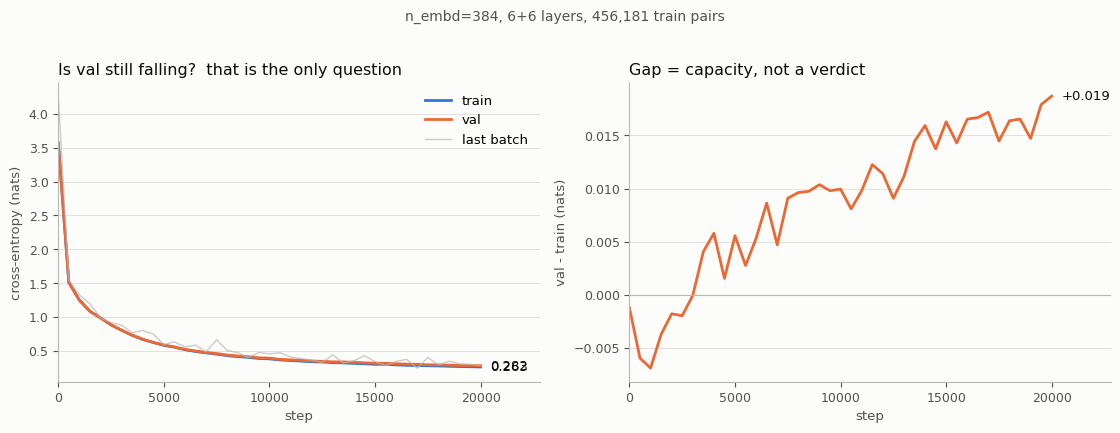

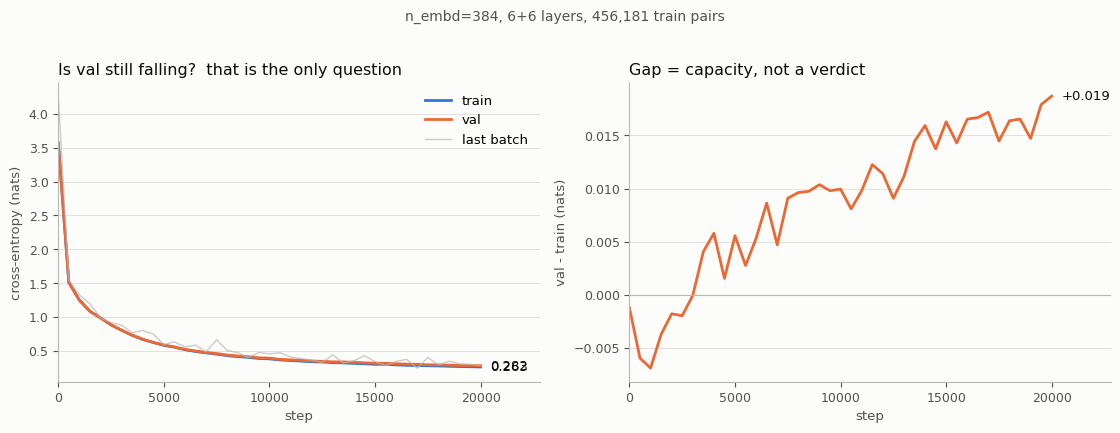

In [143]:
#train
m, history = fit(cnf, getBatch, T_en, T_tr, pad_id_en, pad_id_tr, stoi_en, stoi_tr, device)

plot_training(history, title=f"n_embd={cnf.n_embd}, {cnf.n_layer}+{cnf.n_layer} layers, "
                            f"{len(tr_rows):,} train pairs")

In [7]:
#resume training
m, history = resume_fit("translator_best_0.2539.pt", Config(), getBatch,
                        pad_id_en, pad_id_tr, device, extra_iters=5000)

resumed from translator_best_0.2539.pt
  step 25,000   saved val 0.2539   Adam moments restored for 476 tensors


  0%|          | 0/5000 [00:00<?, ?it/s]

step 25000: batch 0.3895 | train 0.2350 val 0.2538
step 25500: batch 0.2489 | train 0.2370 val 0.2538
step 26000: batch 0.2429 | train 0.2321 val 0.2514
step 26500: batch 0.2066 | train 0.2299 val 0.2517
step 27000: batch 0.3019 | train 0.2274 val 0.2480
step 27500: batch 0.2100 | train 0.2244 val 0.2454
step 28000: batch 0.1950 | train 0.2268 val 0.2476
step 28500: batch 0.2670 | train 0.2246 val 0.2444
step 29000: batch 0.2319 | train 0.2215 val 0.2432
step 29500: batch 0.2406 | train 0.2165 val 0.2381
step 29999: batch 0.2596 | train 0.2156 val 0.2378
best val (val 0.2378)


In [ ]:
print(f"p(correct) = {math.exp(-best_val):.1%}      perplexity = {math.exp(best_val):.3f}")

ENGLISH (source)              MODEL                         REFERENCE                     
--------------------------------------------------------------------------------------------
you seem a little unsure of   bu günlerin günlerini biraz   bugünlerde kendinden biraz e  
two passenger ships were sun  iki angaj için iki karışırdı  iki yolcu gemisi battı.       
tom died three years ago of   tom üç yıl önce yıl önce yıl  tom üç yıl önce zatürreden ö  
i'd like to make a person-to  japonya'ya bir japonya'ya ge  japonya ile şehirler arası i  
i hope i did that correctly.  umarım onu doğru yaptığımı u  umarım bunu doğru yapmışımdı  
they weren't drunk.           onlar arkadaş değildi.        onlar sarhoş değildi.         
i think i'll be able to do t  sanırım bunu tek başıma yapa  sanırım onu tek başıma yapab  
if you want me, i'll be in m  beni istiyorsan olmamı ister  beni istiyorsan, ofisimde ol  
i know that tom is a good st  tom'un iyi bir öğrenci olduğ  tom'un iyi bir öğrenci olduğ

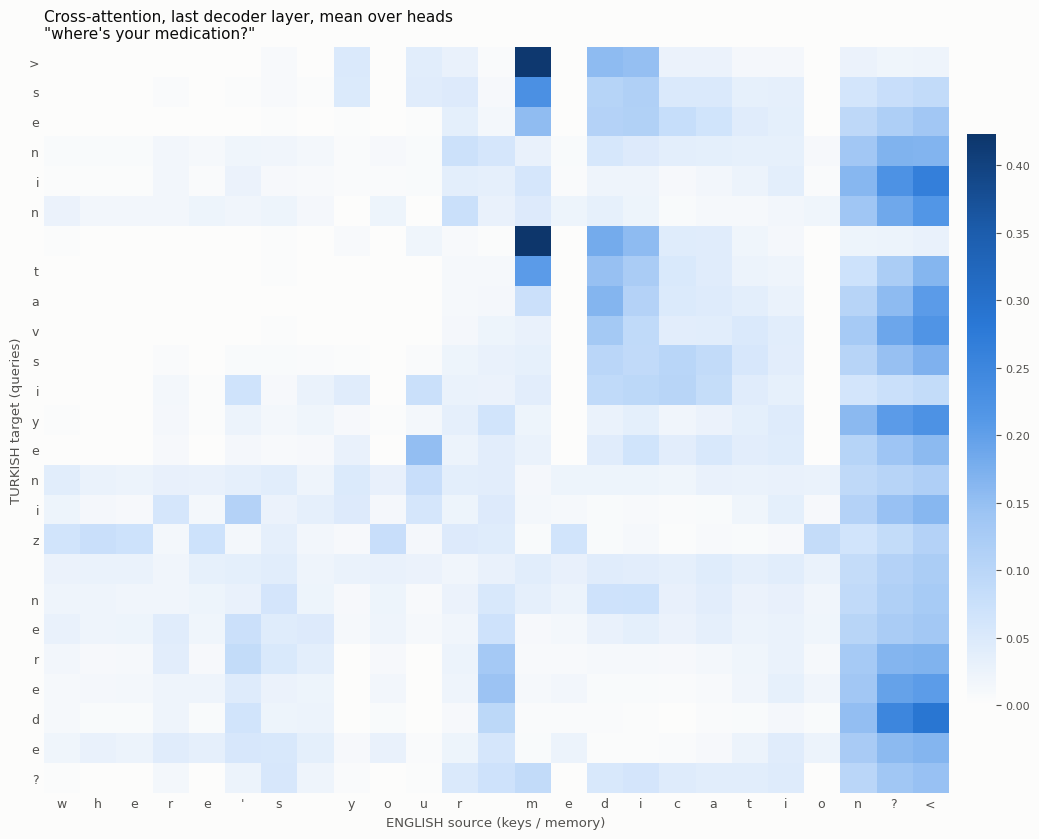

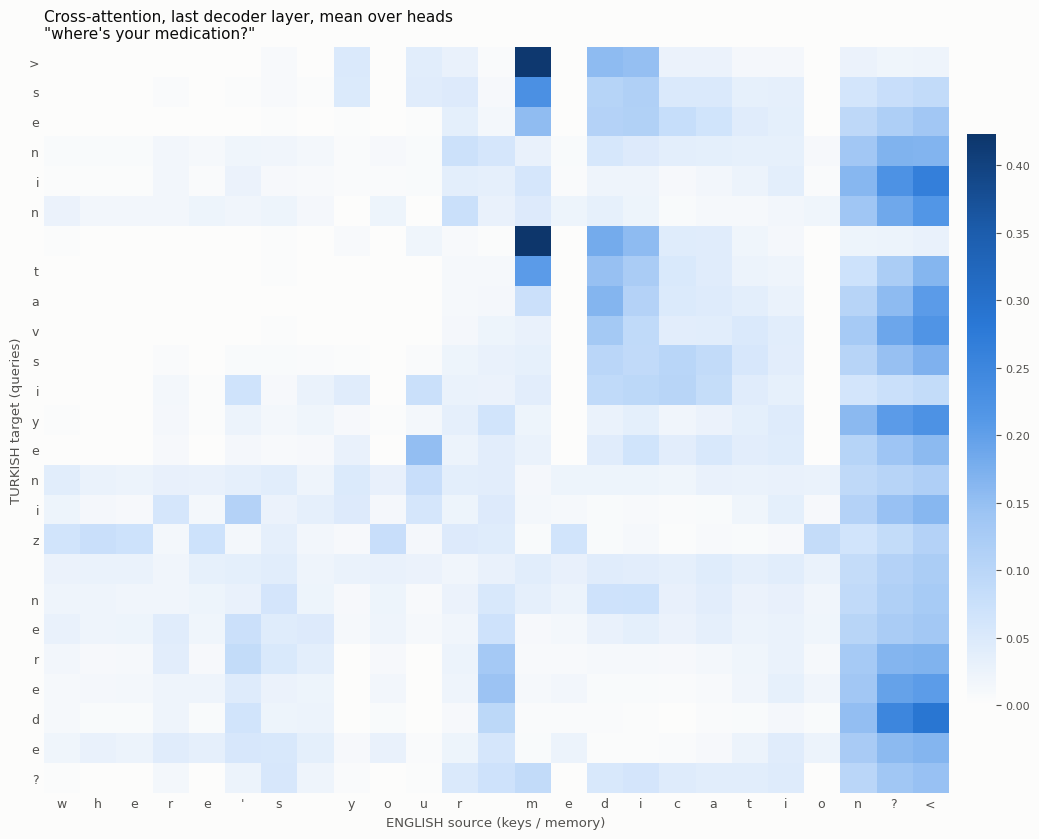

In [144]:
# sample inferences
ckpt = sorted(glob.glob('translator_best_*.pt'))[-1]
translator_model, translate_sentence = InferenceByTrainedModel(
    ckpt, encode_en, decode_tr, eos_id_tr, device)

show_translations(translate_sentence, va_rows, n=10)

s = va_rows[0][0]
attn, en_chars, tr_chars = cross_attention_map(translator_model, s, encode_en, stoi_en, itos_tr, T_en, T_tr, device)
plot_cross_attention(attn, en_chars, tr_chars, s)

In [ ]:
# simple translate
@torch.no_grad()
def say(sentence_en, translator_model=m):

    #check the input
    seen = normalize_english(sentence_en)
    print(f"  model sees : {seen!r}")
    unknown = sorted({c for c in seen if c not in stoi_en})
    if unknown:
        print(f"  NOT IN VOCAB (-> <UNK>): {unknown}")

    #translate
    ids = encode_en(sentence_en) + [eos_id_en]
    ids = ids + [pad_id_en] * (T_en - len(ids))
    src = torch.tensor([ids], dtype=torch.long, device=device)
    out = translator_model.translate(src, max_new_tokens=T_tr)[0].tolist()[1:]   # drop BOS

    if eos_id_tr in out:
        out = out[:out.index(eos_id_tr)]                                         # cut at EOS

    return decode_tr(out)


In [160]:
say("she cleaned the house yesterday")

KeyboardInterrupt: 